<a href="https://colab.research.google.com/github/akashvoffi-design/WorkSpace-ML/blob/main/Sleep_Quality_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)

sns.set_style("whitegrid")


In [4]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print(df.shape)
df.head()

(374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
# INITIAL EXPLORATION
print(df.info())
print(df.isnull().sum())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None
Person ID        

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [6]:
#CLEAN COLUMN NAMES & HANDLE MISSING VALUES
# ------------------------------------------------------------
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# 219 of 374 rows have no Sleep Disorder -> that means "None", not missing data
df["sleep_disorder"] = df["sleep_disorder"].fillna("None")

# Drop the ID column, it carries no predictive signal
df = df.drop(columns=["person_id"])


sleep_quality_label
Average    189
Good       180
Poor         5
Name: count, dtype: int64


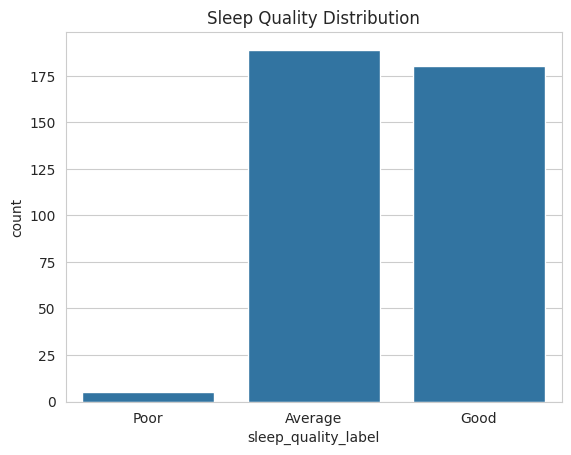

In [9]:
# CREATE THE TARGET LABEL: Good / Average / Poor
def bucket_quality(score):
    if score >= 8:
        return "Good"
    elif score >= 5:
        return "Average"
    else:
        return "Poor"

df["sleep_quality_label"] = df["quality_of_sleep"].apply(bucket_quality)
print(df["sleep_quality_label"].value_counts())

sns.countplot(x="sleep_quality_label", data=df, order=["Poor", "Average", "Good"])
plt.title("Sleep Quality Distribution")
plt.show()



In [10]:
#SPLIT BLOOD PRESSURE INTO SYSTOLIC / DIASTOLIC
bp_split = df["blood_pressure"].str.split("/", expand=True)
df["systolic_bp"] = bp_split[0].astype(float)
df["diastolic_bp"] = bp_split[1].astype(float)
df = df.drop(columns=["blood_pressure"])

In [11]:
# SELECT FEATURES
features = [
    "gender", "age", "occupation", "sleep_duration",
    "physical_activity_level", "stress_level", "bmi_category",
    "heart_rate", "daily_steps", "systolic_bp", "diastolic_bp",
    "sleep_disorder"
]

X = df[features].copy()
y = df["sleep_quality_label"].copy()


In [12]:
# [8] ENCODE CATEGORICAL FEATURES

categorical_cols = ["gender", "occupation", "bmi_category", "sleep_disorder"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)   # Good/Average/Poor -> 0/1/2
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


{'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}


In [16]:
#TRAIN / TEST SPLIT + SCALING
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    results[name] = {"model": model, "accuracy": acc, "f1": f1, "preds": preds}
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))



Logistic Regression
Accuracy: 0.9600 | Weighted F1: 0.9534
              precision    recall  f1-score   support

     Average       0.97      0.95      0.96        38
        Good       0.95      1.00      0.97        36
        Poor       0.00      0.00      0.00         1

    accuracy                           0.96        75
   macro avg       0.64      0.65      0.64        75
weighted avg       0.95      0.96      0.95        75


Decision Tree
Accuracy: 0.9733 | Weighted F1: 0.9753
              precision    recall  f1-score   support

     Average       1.00      0.95      0.97        38
        Good       0.97      1.00      0.99        36
        Poor       0.50      1.00      0.67         1

    accuracy                           0.97        75
   macro avg       0.82      0.98      0.88        75
weighted avg       0.98      0.97      0.98        75


Random Forest
Accuracy: 0.9867 | Weighted F1: 0.9867
              precision    recall  f1-score   support

     Average   

                 Model  Accuracy  F1 Score
2        Random Forest  0.986667  0.986669
1        Decision Tree  0.973333  0.975287
3                  SVM  0.973333  0.966758
0  Logistic Regression  0.960000  0.953427


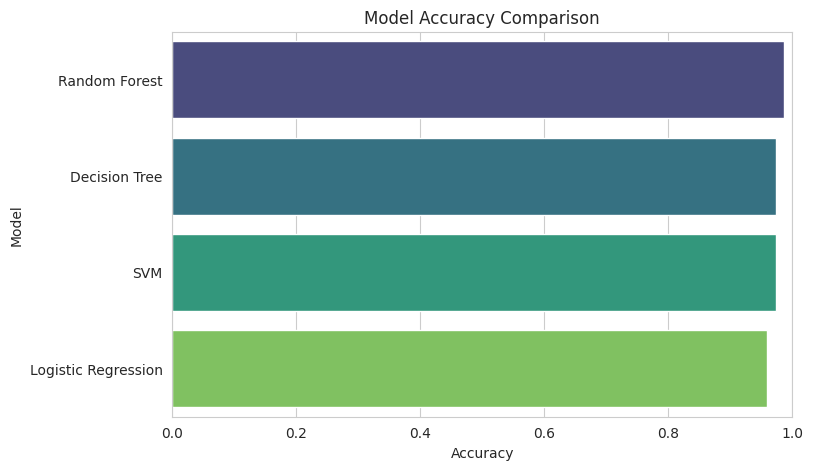

In [20]:
# COMPARE MODELS VISUALLY

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [v["accuracy"] for v in results.values()],
    "F1 Score": [v["f1"] for v in results.values()]
}).sort_values("Accuracy", ascending=False)

print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()


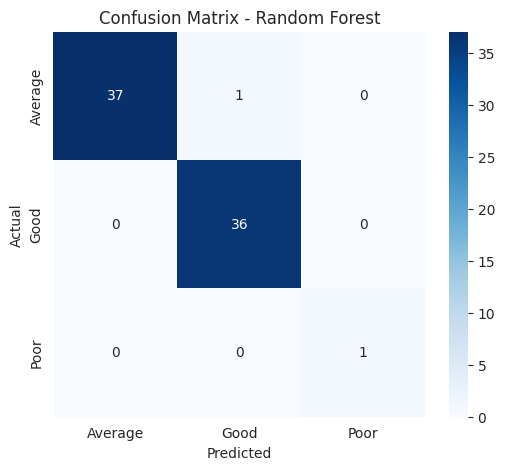


Best model: Random Forest


In [21]:
#CONFUSION MATRIX FOR BEST MODEL

best_model_name = comparison_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
best_preds = results[best_model_name]["preds"]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"\nBest model: {best_model_name}")


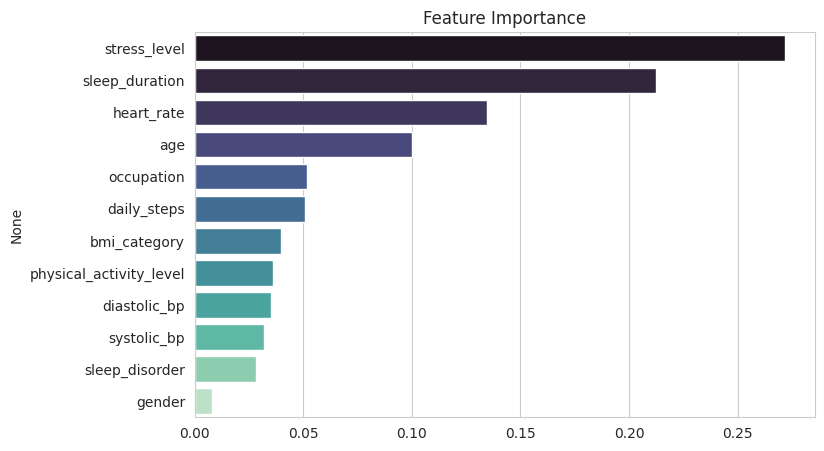

In [22]:
# FEATURE IMPORTANCE (for tree-based models)

if best_model_name in ["Random Forest", "Decision Tree"]:
    importances = pd.Series(best_model.feature_importances_, index=features)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title("Feature Importance")
    plt.show()


In [23]:
# HYPERPARAMETER TUNING (OPTIONAL, for the best model)

if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8, None],
        "min_samples_split": [2, 5, 10]
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42),
                         param_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print("Best params:", grid.best_params_)
    best_model = grid.best_estimator_
    print("Tuned accuracy:", accuracy_score(y_test, best_model.predict(X_test_scaled)))



Best params: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
Tuned accuracy: 1.0


In [24]:
#  SAVE MODEL + PREPROCESSING OBJECTS

joblib.dump(best_model, "sleep_quality_model.pkl")
joblib.dump(scaler, "sleep_quality_scaler.pkl")
joblib.dump(label_encoders, "sleep_quality_label_encoders.pkl")
joblib.dump(target_encoder, "sleep_quality_target_encoder.pkl")
joblib.dump(features, "sleep_quality_features.pkl")
print("Saved: model, scaler, encoders, feature list")

Saved: model, scaler, encoders, feature list


In [25]:
#  PREDICTION FUNCTION FOR NEW USER INPUT

def predict_sleep_quality(user_input: dict):
    """
    user_input example:
    {
        "gender": "Male",
        "age": 25,
        "occupation": "Software Engineer",
        "sleep_duration": 6.0,
        "physical_activity_level": 40,
        "stress_level": 7,
        "bmi_category": "Normal",
        "heart_rate": 75,
        "daily_steps": 6000,
        "systolic_bp": 122,
        "diastolic_bp": 80,
        "sleep_disorder": "None"
    }
    """
    row = pd.DataFrame([user_input])[features]

    for col in categorical_cols:
        le = label_encoders[col]
        row[col] = row[col].astype(str).apply(
            lambda v: v if v in le.classes_ else le.classes_[0]
        )
        row[col] = le.transform(row[col])

    row_scaled = scaler.transform(row)
    pred = best_model.predict(row_scaled)[0]
    label = target_encoder.inverse_transform([pred])[0]

    tips = {
        "Poor": [
            "Try reducing screen time by at least 30 minutes before bed.",
            "Aim for 7-8 hours of consistent sleep duration.",
            "Lower stress before bedtime with breathing exercises or journaling."
        ],
        "Average": [
            "Increase physical activity during the day for deeper sleep.",
            "Keep a consistent bedtime and wake-up time.",
            "Cut caffeine intake after early afternoon."
        ],
        "Good": [
            "Great job! Keep maintaining your current sleep routine.",
            "Continue balancing activity, stress, and screen time."
        ]
    }

    return {"predicted_quality": label, "tips": tips[label]}

In [26]:
sample_user = {
    "gender": "Male",
    "age": 22,
    "occupation": "Software Engineer",
    "sleep_duration": 5.5,
    "physical_activity_level": 30,
    "stress_level": 8,
    "bmi_category": "Normal",
    "heart_rate": 80,
    "daily_steps": 4000,
    "systolic_bp": 128,
    "diastolic_bp": 84,
    "sleep_disorder": "Insomnia"
}

result = predict_sleep_quality(sample_user)
print(result)


{'predicted_quality': 'Average', 'tips': ['Increase physical activity during the day for deeper sleep.', 'Keep a consistent bedtime and wake-up time.', 'Cut caffeine intake after early afternoon.']}


In [27]:
# (OPTIONAL) LOAD MODEL LATER WITHOUT RETRAINING

best_model = joblib.load("sleep_quality_model.pkl")
scaler = joblib.load("sleep_quality_scaler.pkl")
label_encoders = joblib.load("sleep_quality_label_encoders.pkl")
target_encoder = joblib.load("sleep_quality_target_encoder.pkl")
features = joblib.load("sleep_quality_features.pkl")
